In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, GlobalMaxPooling1D, Dense, LSTM, SimpleRNN, Dropout
from tensorflow.keras.utils import to_categorical
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import InputExample, InputFeatures

In [2]:
# Load your dataset here (you can replace with your full dataset)
df = pd.read_csv("Reviews.csv")  # Assume columns: 'Text', 'Score'

In [3]:
# Convert score to sentiment

def map_sentiment(score):
    if score >= 4:
        return 1  # Positive
    elif score == 3:
        return 0  # Neutral
    else:
        return -1  # Negative

df['Sentiment'] = df['Score'].apply(map_sentiment)

In [4]:
# Preprocessing
X = df['Text']
y = df['Sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [5]:
# Tokenization for CNN/RNN/LSTM
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)


# CNN

In [6]:
cnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train, epochs=5, batch_size=64, validation_split=0.2)

C:\Users\ATHAK\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 234s 41ms/step - accuracy: 0.8609 - loss: 0.3804 - val_accuracy: 0.9065 - val_loss: 0.2597
Epoch 2/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 227s 40ms/step - accuracy: 0.9257 - loss: 0.2067 - val_accuracy: 0.9122 - val_loss: 0.2475
Epoch 3/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 224s 39ms/step - accuracy: 0.9534 - loss: 0.1329 - val_accuracy: 0.9138 - val_loss: 0.2734
Epoch 4/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 230s 40ms/step - accuracy: 0.9724 - loss: 0.0805 - val_accuracy: 0.9115 - val_loss: 0.3012
Epoch 5/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 226s 40ms/step - accuracy: 0.9823 - loss: 0.0512 - val_accuracy: 0.9082 - val_loss: 0.3620


# RNN

In [7]:
rnn_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

rnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.fit(X_train_seq, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 213s 37ms/step - accuracy: 0.8220 - loss: 0.4976 - val_accuracy: 0.8244 - val_loss: 0.4734
Epoch 2/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 203s 36ms/step - accuracy: 0.8190 - loss: 0.5009 - val_accuracy: 0.8085 - val_loss: 0.5841
Epoch 3/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 203s 36ms/step - accuracy: 0.8185 - loss: 0.5066 - val_accuracy: 0.8166 - val_loss: 0.5337
Epoch 4/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 217s 38ms/step - accuracy: 0.8104 - loss: 0.5259 - val_accuracy: 0.7985 - val_loss: 0.5794
Epoch 5/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 205s 36ms/step - accuracy: 0.8059 - loss: 0.5436 - val_accuracy: 0.8237 - val_loss: 0.4984


# LSTM

In [8]:
lstm_model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train, epochs=5, batch_size=64, validation_split=0.2)


Epoch 1/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 379s 66ms/step - accuracy: 0.8498 - loss: 0.4154 - val_accuracy: 0.8896 - val_loss: 0.2972
Epoch 2/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 377s 66ms/step - accuracy: 0.9050 - loss: 0.2568 - val_accuracy: 0.9034 - val_loss: 0.2660
Epoch 3/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 378s 66ms/step - accuracy: 0.9265 - loss: 0.2040 - val_accuracy: 0.9105 - val_loss: 0.2632
Epoch 4/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 381s 67ms/step - accuracy: 0.9422 - loss: 0.1616 - val_accuracy: 0.9112 - val_loss: 0.2746
Epoch 5/5
5685/5685 ━━━━━━━━━━━━━━━━━━━━ 379s 67ms/step - accuracy: 0.9552 - loss: 0.1268 - val_accuracy: 0.9106 - val_loss: 0.2806


# EVALUATION

3553/3553 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step
Classification Report for cnn:
              precision    recall  f1-score   support

          -1       0.85      0.78      0.81     16181
           0       0.58      0.59      0.58      8485
           1       0.95      0.96      0.96     89025

    accuracy                           0.91    113691
   macro avg       0.79      0.78      0.78    113691
weighted avg       0.91      0.91      0.91    113691



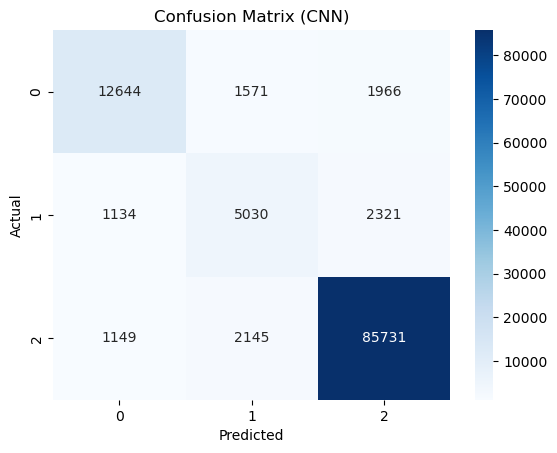

3553/3553 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step
Classification Report for rnn:
              precision    recall  f1-score   support

          -1       0.61      0.49      0.54     16181
           0       0.49      0.02      0.03      8485
           1       0.85      0.96      0.91     89025

    accuracy                           0.83    113691
   macro avg       0.65      0.49      0.49    113691
weighted avg       0.79      0.83      0.79    113691



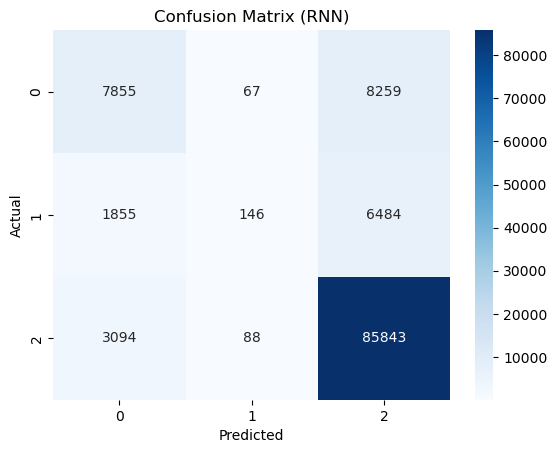

3553/3553 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step
Classification Report for lstm:
              precision    recall  f1-score   support

          -1       0.82      0.80      0.81     16181
           0       0.62      0.49      0.55      8485
           1       0.95      0.97      0.96     89025

    accuracy                           0.91    113691
   macro avg       0.80      0.75      0.77    113691
weighted avg       0.91      0.91      0.91    113691



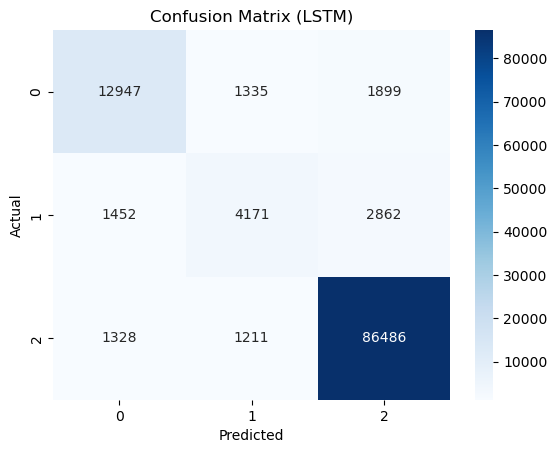

In [13]:
def evaluate_model(model, X, y_true, model_type):
    preds = model.predict(X)
    y_pred = np.argmax(preds, axis=1)
    y_true = np.argmax(y_true, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred, target_names=le.classes_.astype(str), output_dict=True)
    print(f"Classification Report for {model_type}:")
    print(classification_report(y_true, y_pred, target_names=le.classes_.astype(str)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({model_type.upper()})")
    plt.show()
    return cr['accuracy']

# Evaluate and store accuracies
cnn_acc = evaluate_model(cnn_model, X_test_seq, y_test, model_type="cnn")
rnn_acc = evaluate_model(rnn_model, X_test_seq, y_test, model_type="rnn")
lstm_acc = evaluate_model(lstm_model, X_test_seq, y_test, model_type="lstm")

# Comparison table

In [15]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['CNN', 'RNN', 'LSTM'],
    'Accuracy': [cnn_acc, rnn_acc, lstm_acc]
})

print("\nModel Comparison Table:")
print(results)



Model Comparison Table:
  Model  Accuracy
0   CNN  0.909527
1   RNN  0.825430
2  LSTM  0.911277


C:\Users\ATHAK\AppData\Local\Temp\ipykernel_14088\3668044595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')


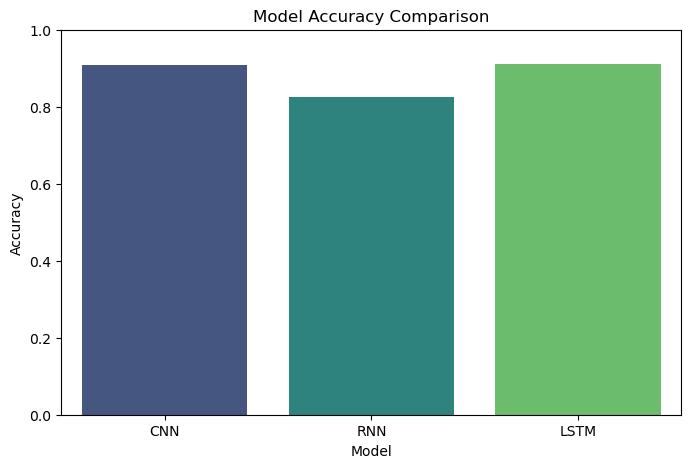

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

In [22]:
# Save models
cnn_model.save("cnn_model.h5")
rnn_model.save("rnn_model.h5")
lstm_model.save("lstm_model.h5")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
